Goal: helping the company identify high-value customer segments, prioritize marketing efforts, and develop more effective customer retention strategies.

Approach: using publicly available e-commerce transaction data and supervised machine learning techniques to build a model that predicts which customers are most likely to become repeat purchasers.

Successful outcome: build a model that predicts repeat customers and provides actionable marketing recommendations

# Setup

In [4]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_excel('https://raw.githubusercontent.com/Break-Through-Tech/witOmni-1A-ai-powered-customer-intelligence-for-smarter-marketing/main/data/Online%20Retail.xlsx', header=0)

#### Alternate dataset import

In [6]:
%pip install openpyxl

In [7]:

df = pd.read_excel('../data/Online Retail.xlsx')

FileNotFoundError: [Errno 2] No such file or directory: '../data/Online Retail.xlsx'

#### Dataset Info

In [ ]:
df.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Hour,DayOfWeek,Month
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850,15.30,8,Wednesday,December
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850,20.34,8,Wednesday,December
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850,22.00,8,Wednesday,December
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850,20.34,8,Wednesday,December
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850,20.34,8,Wednesday,December


Data type: Numerical and nominal

Format: CSV / Structured tabular data

Feature Type: Integer, Real

Instances: 541909

Features: 6

Data set size: 22.6 MB


Ethical Concerns: 

The Country section on the UCI Online Retail dataset may lead to discrimination toward certain nationalities or ethnic groups. 

Those with lower income may not be classified as “high-value customers” and focusing marketing efforts away from them could push them farther away from becoming repeat buyers


# Business Understanding

Problem: Founder-led companies (WitOmni's target clientele) have access to large amounts of customer transaction data but not many have the resources to turn that data into actionable marketing insights. 

Goal: Use historical e-commerce transaction data to better understand customer puchasing behavior and identify repeat customers so that marketing resources can prioritize customers with the greatest potential for retention and long-term value. 

Approach: Analyze publicly available e-commerce transaction data and supervised machine learning techniques to build and compare classification models that predict whether a customer is likely to make a repeat purchase.

Successful outcome: Build and compare multiple classification models. Evaluate models using precision, recall, and F1-score. Select the best performing model at predicting repeat customers by the purchase features. Translate model results into understandable marketing recommendations and clearly communicate the potential action items and limitations of the predictions.

Expected Business Value: Turn model predictions into actional recommendations that founders can leverage for their marketing strategy. By identifying customer segments, particularly those who are likely to become repeat customers, the founders can increase customer retention for their business. 

May have to one-hot encode categorical data

Clean up any missing data 

Can exclude invoice number, and get rid of data associated with cancelled invoice number (starting with ‘c’)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


# Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
df.shape

(541909, 8)

In [ ]:
print("Duplicate rows: ", df.duplicated().sum())

Duplicate rows:  5268


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(536641, 8)

In [ ]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64


In [ ]:
# removing all the rows w/ missing customerID
df = df.dropna(subset=["CustomerID"])

In [ ]:
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [ ]:
# removing cancellation/returned items
df = df[~df["InvoiceNo"].astype(str).str.upper().str.startswith("C")]

In [ ]:
# removing invalid transactions (invalid prices or quantities)
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]


In [ ]:
# final statistics + check (doing it before dropping non relevant columns)
print(df.dtypes)
print(df.isnull().sum())
print("Duplicate rows: ", df.duplicated().sum())
print("Shape: ", df.shape)
df["CustomerID"] = df["CustomerID"].astype(int)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
Duplicate rows:  0
Shape:  (392692, 8)


In [ ]:
#dropping non relevant columns
df = df.drop(columns=["Description", "Country"])

In [ ]:
print("Final shape: ", df.shape)
print("\nMissing values: ")
print(df.isnull().sum())
print("\nData types: ")
print(df.dtypes)

Final shape:  (392692, 6)

Missing values: 
InvoiceNo      0
StockCode      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
dtype: int64

Data types: 
InvoiceNo              object
StockCode              object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
dtype: object


# Data Exploration

In [ ]:
# 1. Summary stats
df[["Quantity", "UnitPrice", "TotalPrice"]].describe()

,Quantity,UnitPrice,TotalPrice
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [ ]:
# 2. Unique counts
print("Unique customers:", df["CustomerID"].nunique())   # ~4,338
print("Unique invoices:", df["InvoiceNo"].nunique())      # ~18,532
print("Total transactions (rows):", df.shape[0])          # ~392,692

Unique customers: 4338
Unique invoices: 18532
Total transactions (rows): 392692


In [ ]:
# 3. Order value distribution (per invoice)
invoice_totals = df.groupby("InvoiceNo")["TotalPrice"].sum()
invoice_totals.describe()

,TotalPrice
count,18532.00000
mean,479.56016
std,1678.08258
min,0.38000
25%,157.34000
50%,302.57500
75%,469.57000
max,168469.60000


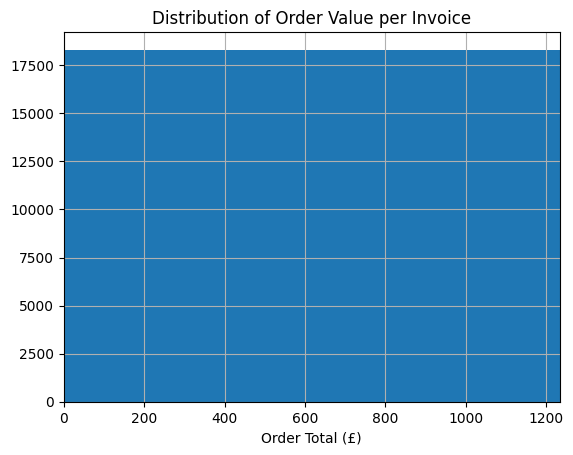

In [ ]:
invoice_totals.hist(bins=50)
plt.xlim(0, invoice_totals.quantile(0.95))
plt.title("Distribution of Order Value per Invoice")
plt.xlabel("Order Total (£)")
plt.show()

In [ ]:
# 4. Orders per customer (frequency)
customer_orders = df.groupby("CustomerID")["InvoiceNo"].nunique()
customer_orders.describe()

,InvoiceNo
count,4338.000000
mean,4.272015
std,7.697998
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,209.000000


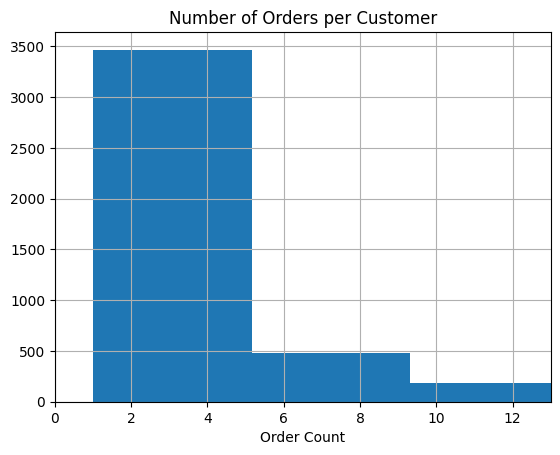

In [ ]:
customer_orders.hist(bins=50)
plt.xlim(0, customer_orders.quantile(0.95))
plt.title("Number of Orders per Customer")
plt.xlabel("Order Count")
plt.show()

In [ ]:
# 5. Outlier check — this dataset has a £168k max TotalPrice, worth flagging
print(df.sort_values("TotalPrice", ascending=False)[["InvoiceNo","Quantity","UnitPrice","TotalPrice"]].head(10))

       InvoiceNo  Quantity  UnitPrice  TotalPrice
540421    581483     80995       2.08   168469.60
61619     541431     74215       1.04    77183.60
222680    556444        60     649.50    38970.00
173382    551697         1    8142.75     8142.75
348325    567423      1412       5.06     7144.72
160546    550461      3114       2.10     6539.40
52711     540815      3114       2.10     6539.40
421601    573003      2400       2.08     4992.00
52709     540815      1930       2.55     4921.50
160542    550461      1930       2.40     4632.00


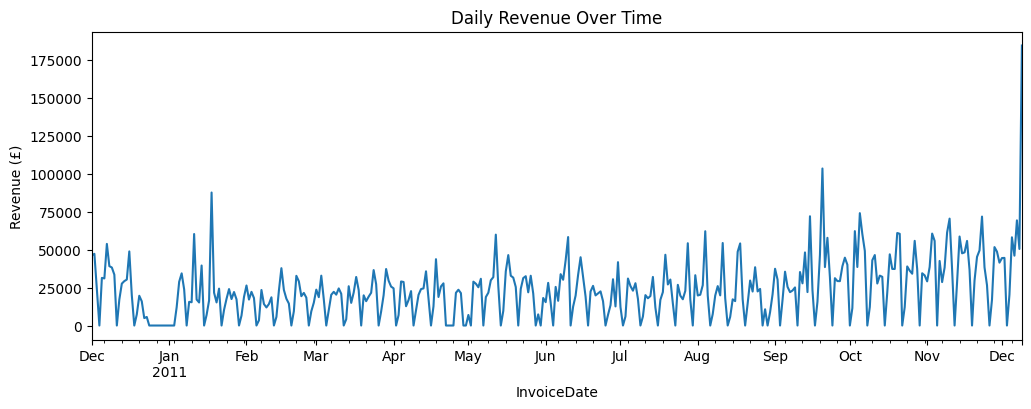

In [ ]:
# 6. Revenue over time — your data spans Dec 2010 to Dec 2011
df.set_index("InvoiceDate")["TotalPrice"].resample("D").sum().plot(figsize=(12,4))
plt.title("Daily Revenue Over Time")
plt.ylabel("Revenue (£)")
plt.show()

In [ ]:
# Extract useful time features
df["Hour"] = df["InvoiceDate"].dt.hour
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Month"] = df["InvoiceDate"].dt.month_name()

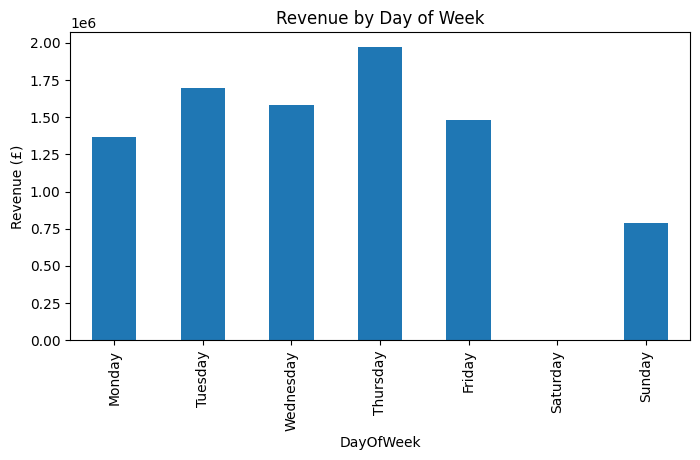

In [ ]:
# 1. Revenue by day of week — are weekends slower for B2B-style wholesale?
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df.groupby("DayOfWeek")["TotalPrice"].sum().reindex(order).plot(kind="bar", figsize=(8,4))
plt.title("Revenue by Day of Week")
plt.ylabel("Revenue (£)")
plt.show()

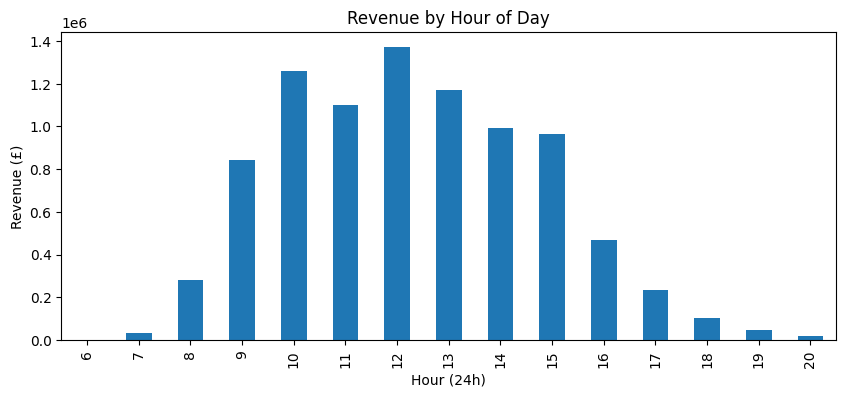

In [ ]:
# 2. Revenue by hour of day — when do purchases happen?
df.groupby("Hour")["TotalPrice"].sum().plot(kind="bar", figsize=(10,4))
plt.title("Revenue by Hour of Day")
plt.xlabel("Hour (24h)")
plt.ylabel("Revenue (£)")
plt.show()

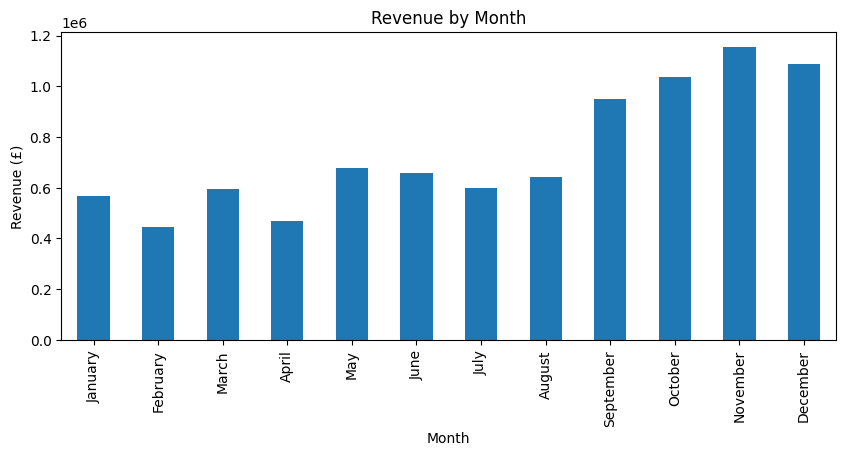

In [ ]:
# 3. Revenue by month — check for seasonality (your data spans Dec 2010–Dec 2011)
month_order = ["January","February","March","April","May","June","July",
                "August","September","October","November","December"]
df.groupby("Month")["TotalPrice"].sum().reindex(month_order).plot(kind="bar", figsize=(10,4))
plt.title("Revenue by Month")
plt.ylabel("Revenue (£)")
plt.show()

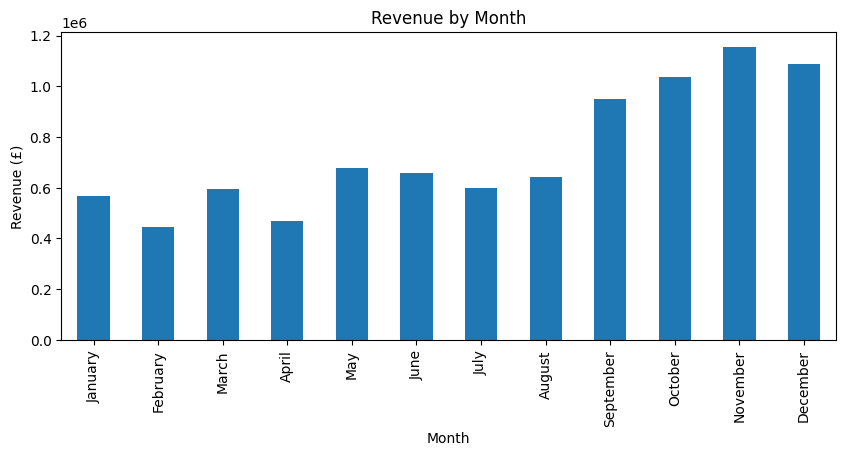

In [ ]:
# 3. Revenue by month — check for seasonality (your data spans Dec 2010–Dec 2011)
month_order = ["January","February","March","April","May","June","July",
                "August","September","October","November","December"]
df.groupby("Month")["TotalPrice"].sum().reindex(month_order).plot(kind="bar", figsize=(10,4))
plt.title("Revenue by Month")
plt.ylabel("Revenue (£)")
plt.show()

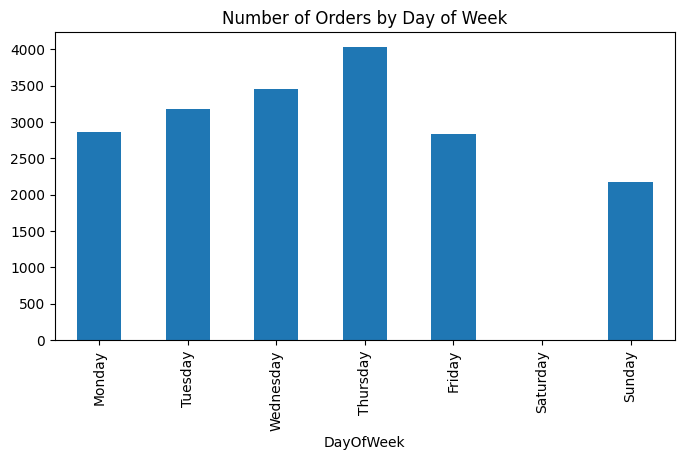

In [ ]:
# 4. Number of orders by day of week (frequency, not just £)
df.groupby("DayOfWeek")["InvoiceNo"].nunique().reindex(order).plot(kind="bar", figsize=(8,4))
plt.title("Number of Orders by Day of Week")
plt.show()

In [ ]:
print(df.shape)
print(df.isnull().sum())
print(df["Quantity"].min(), df["UnitPrice"].min())

(392692, 10)
InvoiceNo      0
StockCode      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
TotalPrice     0
Hour           0
DayOfWeek      0
Month          0
dtype: int64
1 0.001


# Customer Feature Engineering

In [13]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [14]:
# recency, frequency, monetary, total quantity of items customers bought
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (df["InvoiceDate"].max() - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    total_quantity=('Quantity', 'sum')
).reset_index()
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,total_quantity
0,12346.0,325,2,0.00,0
1,12347.0,1,7,4310.00,2458
2,12348.0,74,4,1797.24,2341
3,12349.0,18,1,1757.55,631
4,12350.0,309,1,334.40,197
5,12352.0,35,11,1545.41,470
6,12353.0,203,1,89.00,20
7,12354.0,231,1,1079.40,530
8,12355.0,213,1,459.40,240
9,12356.0,22,3,2811.43,1591


In [15]:
rfm["average_order_value"] = rfm['Monetary'] / rfm['Frequency'] 
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,total_quantity,average_order_value
0,12346.0,325,2,0.00,0,0.000000
1,12347.0,1,7,4310.00,2458,615.714286
2,12348.0,74,4,1797.24,2341,449.310000
3,12349.0,18,1,1757.55,631,1757.550000
4,12350.0,309,1,334.40,197,334.400000
5,12352.0,35,11,1545.41,470,140.491818
6,12353.0,203,1,89.00,20,89.000000
7,12354.0,231,1,1079.40,530,1079.400000
8,12355.0,213,1,459.40,240,459.400000
9,12356.0,22,3,2811.43,1591,937.143333


In [16]:
# product diversity / breadth features

# unique products purchased per customer
unique_products = df.groupby('CustomerID')['StockCode'].nunique().rename('unique_products').reset_index()
rfm = rfm.merge(unique_products, on='CustomerID', how='left')

# product diversity ratio = unique products / total quantity purchased
rfm['product_diversity_ratio'] = rfm['unique_products'] / rfm['total_quantity']
rfm['product_diversity_ratio'] = rfm['product_diversity_ratio'].replace([np.inf, -np.inf], np.nan)

# repeat purchase rate = % of a customer's distinct products bought more than once
product_counts = df.groupby(['CustomerID', 'StockCode']).size().reset_index(name='purchase_count')
repeat_rate = (
    product_counts.groupby('CustomerID')['purchase_count']
    .apply(lambda x: (x > 1).mean())
    .rename('repeat_purchase_rate')
    .reset_index()
)
rfm = rfm.merge(repeat_rate, on='CustomerID', how='left')

rfm.head(20)

,CustomerID,Recency,Frequency,Monetary,total_quantity,average_order_value,unique_products,product_diversity_ratio,repeat_purchase_rate
0,12346.0,325,2,0.00,0,0.000000,1,NaN,1.000000
1,12347.0,1,7,4310.00,2458,615.714286,103,0.041904,0.417476
2,12348.0,74,4,1797.24,2341,449.310000,22,0.009398,0.318182
3,12349.0,18,1,1757.55,631,1757.550000,73,0.115689,0.000000
4,12350.0,309,1,334.40,197,334.400000,17,0.086294,0.000000
5,12352.0,35,11,1545.41,470,140.491818,59,0.125532,0.322034
6,12353.0,203,1,89.00,20,89.000000,4,0.200000,0.000000
7,12354.0,231,1,1079.40,530,1079.400000,58,0.109434,0.000000
8,12355.0,213,1,459.40,240,459.400000,13,0.054167,0.000000
9,12356.0,22,3,2811.43,1591,937.143333,53,0.033312,0.075472


# Data Visualization


In [17]:
df.corr(method='pearson', numeric_only = True)

,Quantity,UnitPrice,CustomerID,TotalPrice
Quantity,1.000000,-0.001235,-0.003600,0.886681
UnitPrice,-0.001235,1.000000,-0.004560,-0.162029
CustomerID,-0.003600,-0.004560,1.000000,-0.002274
TotalPrice,0.886681,-0.162029,-0.002274,1.000000


<Axes: title={'center': 'Distribution of Total Price'}, ylabel='Frequency'>

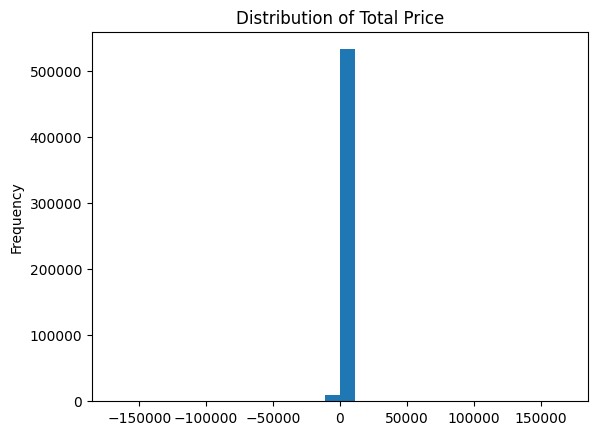

In [18]:
df['TotalPrice'].plot(kind='hist', bins=30, title = "Distribution of Total Price")

<Axes: title={'center': 'Box Plot of Total Price'}>

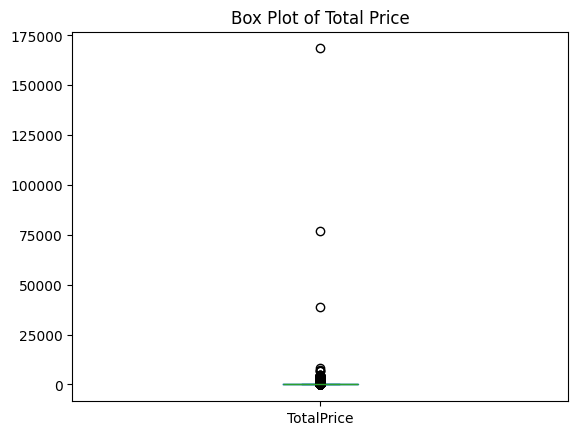

In [ ]:
df['TotalPrice'].plot(kind='box', title='Box Plot of Total Price')


<Axes: ylabel='Frequency'>

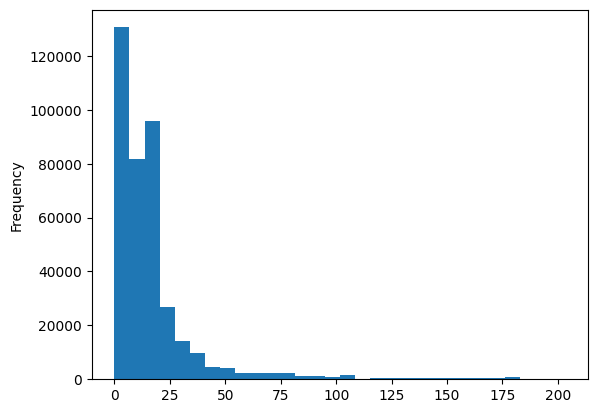

In [ ]:
q_high = df['TotalPrice'].quantile(0.99)
df[df['TotalPrice'] < q_high]['TotalPrice'].plot(kind='hist', bins=30)

<Axes: >

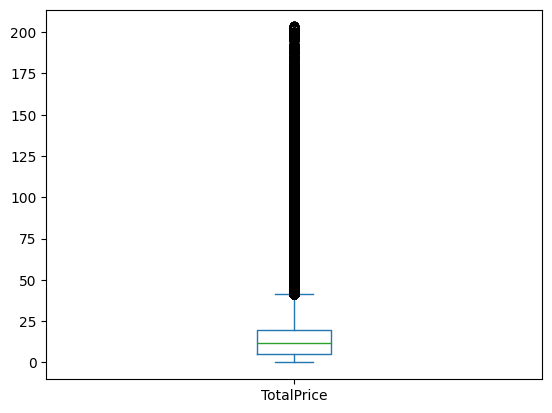

In [ ]:
df[df['TotalPrice'] < q_high]['TotalPrice'].plot(kind='box')

<Axes: title={'center': 'Distribution of Quantity'}, ylabel='Frequency'>

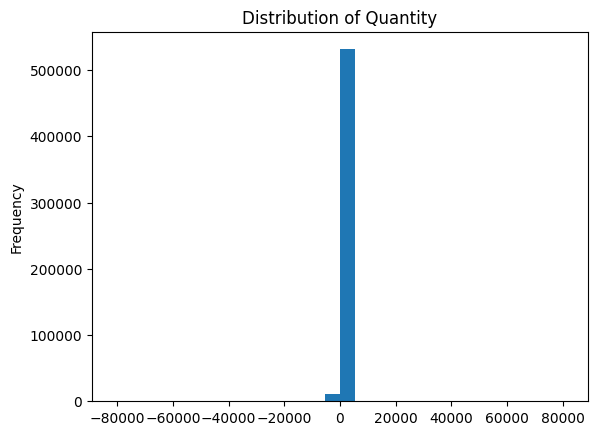

In [8]:
df['Quantity'].plot(kind='hist', bins=30, title = "Distribution of Quantity")

<Axes: title={'center': 'Box Plot of Quantity'}>

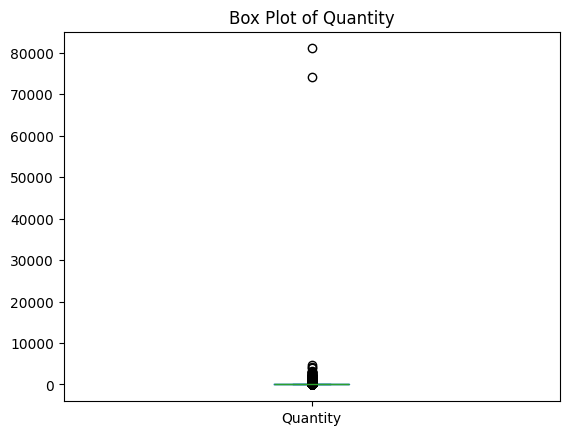

In [ ]:
df['Quantity'].plot(kind='box', title='Box Plot of Quantity')


In [19]:
rfm.corr(method='pearson', numeric_only = True)

,CustomerID,Recency,Frequency,Monetary,total_quantity,average_order_value,unique_products,product_diversity_ratio,repeat_purchase_rate
CustomerID,1.000000,0.013687,-0.019309,-0.012563,-0.019412,-0.104252,-0.008098,0.096069,-0.005054
Recency,0.013687,1.000000,-0.259342,-0.132001,-0.136406,-0.080099,-0.302662,0.029936,-0.317402
Frequency,-0.019309,-0.259342,1.000000,0.566122,0.574169,0.087525,0.695663,-0.101431,0.449141
Monetary,-0.012563,-0.132001,0.566122,1.000000,0.921649,0.420078,0.412015,-0.078718,0.257206
total_quantity,-0.019412,-0.136406,0.574169,0.921649,1.000000,0.381655,0.440926,-0.090148,0.261159
average_order_value,-0.104252,-0.080099,0.087525,0.420078,0.381655,1.000000,0.188889,-0.072647,0.054283
unique_products,-0.008098,-0.302662,0.695663,0.412015,0.440926,0.188889,1.000000,0.046118,0.298209
product_diversity_ratio,0.096069,0.029936,-0.101431,-0.078718,-0.090148,-0.072647,0.046118,1.000000,-0.138274
repeat_purchase_rate,-0.005054,-0.317402,0.449141,0.257206,0.261159,0.054283,0.298209,-0.138274,1.000000


<Axes: title={'center': 'Distribution of average order value'}, ylabel='Frequency'>

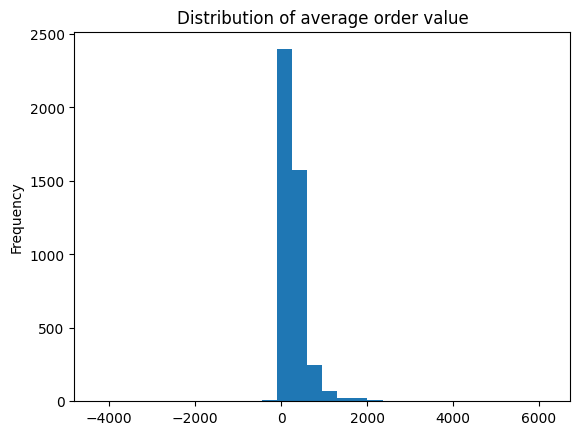

In [28]:
rfm["average_order_value"].plot(kind='hist', bins=30, title = "Distribution of average order value")

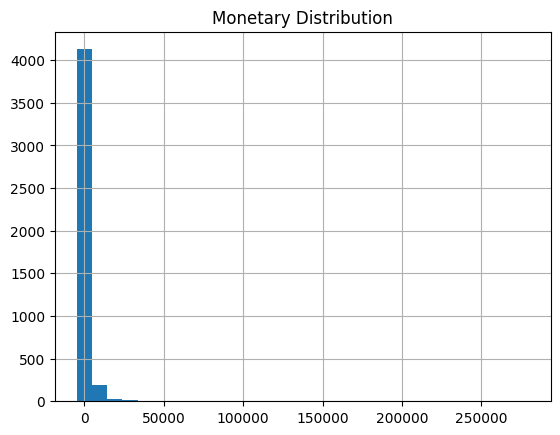

In [21]:
rfm['Monetary'].hist(bins=30)
plt.title('Monetary Distribution')
plt.show()

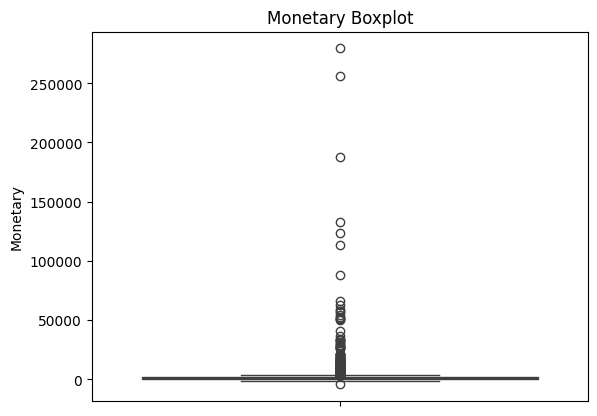

In [22]:
sns.boxplot(y=rfm['Monetary'])
plt.title('Monetary Boxplot')
plt.show()

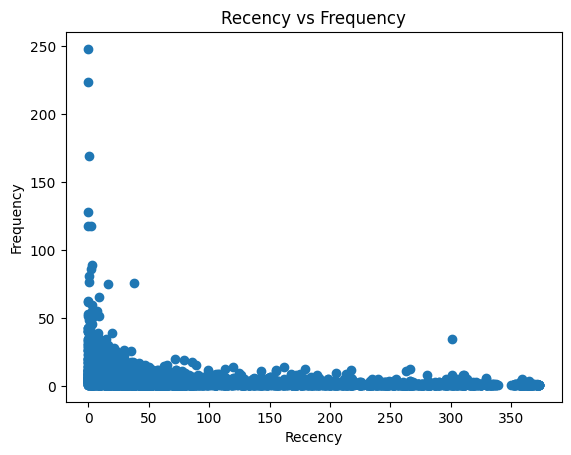

In [23]:
plt.scatter(rfm['Recency'], rfm['Frequency'])
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.title('Recency vs Frequency')
plt.show()

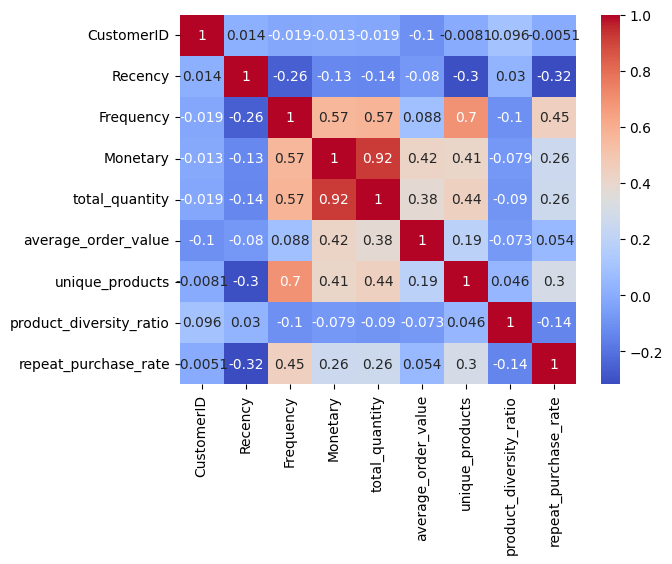

In [24]:
sns.heatmap(rfm.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

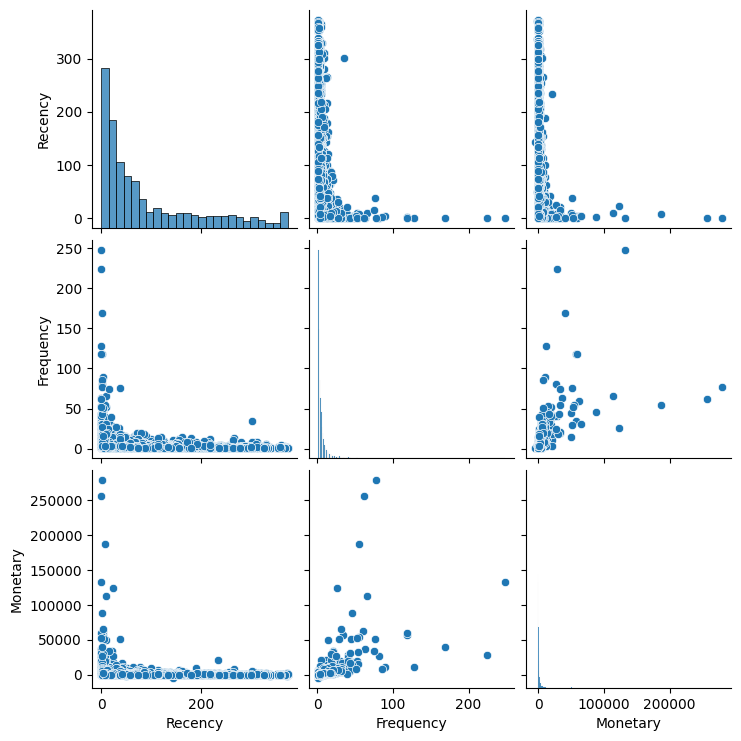

In [25]:
sns.pairplot(rfm[['Recency', 'Frequency', 'Monetary']])
plt.show()

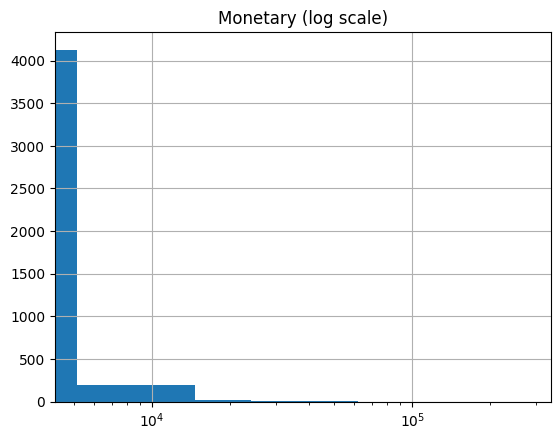

In [26]:
rfm['Monetary'].hist(bins=30)
plt.xscale('log')
plt.title('Monetary (log scale)')
plt.show()